# 2 · Modelagem — resposta, efeito causal do envio e política de ofertas

**Entrada:** `data/processed/modeling_table.parquet` (NB1) — (cliente × onda), 102k
linhas, tratamento **W = envio**, controle limpo por onda, features pré-onda.

## Estrutura (decisões e alternativas descartadas)

| Bloco | O quê | Justificativa | Alternativa descartada |
|---|---|---|---|
| **A** | Split **temporal**: treino ondas 0–14, teste 17–24 | Simula a decisão real (treinar no passado, decidir no futuro) | Split aleatório: vaza o futuro |
| **B** | **ATE do envio**: tratados × controle limpo, gasto em 7d **líquido do reward**, IC bootstrap | Responde "quanto o envio gera de incremento, descontado o cupom" | Atribuir todo o gasto da janela à oferta: ~43% ocorreria sem ela |
| **C** | **Modelo de resposta** `P(viu & usou)` (XGBoost) | Target de negócio definido no case; identifica quem responde | AUC como métrica final da política (não mede incremento) |
| **D** | **CATE** — T-learner por **tipo** (3 braços × controle limpo) no gasto líquido | Efeito heterogêneo com controle real; braços por tipo mantêm amostra; atributos da oferta diferenciam ofertas dentro do braço | T-learner por offer_id: 8 braços finos demais |
| **E** | **Política**: argmax do valor líquido incremental esperado, incluindo "nenhuma"; avaliação por **Qini** e simulação financeira | A entrega é uma regra de alocação, não um score | Ranquear por propensão: prioriza quem compraria de qualquer forma |

**Premissas herdadas do NB1:** envio ~aleatorizado por onda (balance check);
`reward_paid` é da janela da oferta (aproximação ao usar horizonte 7d);
tratados podem ter ofertas anteriores ativas (56% de sobreposição) → ATE também
reportado no recorte "tratado limpo" (sem oferta ativa no envio).


## Setup e carga (dual-mode)
Roda local (parquet de `data/processed/`) ou no Databricks (tabelas salvas pelo
NB1: `ifood_modeling_table` / `ifood_offers` — **rode o NB1 antes no mesmo
workspace**). A célula `%pip` instala o xgboost no serverless (no-op local).

In [ ]:
%pip install -q xgboost

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os, sys, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.calibration import calibration_curve
rng = np.random.RandomState(42)
plt.rcParams['figure.dpi'] = 110
IFOOD_RED = '#EA1D2C'

IS_DATABRICKS = "DATABRICKS_RUNTIME_VERSION" in os.environ
if IS_DATABRICKS:
    FIG = '/tmp/figures'
    df = spark.table('ifood_modeling_table').toPandas()
    offers = spark.table('ifood_offers').toPandas()
else:
    FIG = os.path.abspath(os.path.join('..', 'presentation', 'figures'))
    df = pd.read_parquet('../data/processed/modeling_table.parquet')
    offers = pd.read_parquet('../data/processed/offers.parquet')
os.makedirs(FIG, exist_ok=True)
print("Ambiente:", "Databricks" if IS_DATABRICKS else "local", "|", df.shape)
df.groupby('W').size()

Ambiente: local | (102000, 53)


W
0    25723
1    76277
dtype: int64

### Métrica de avaliação — curva Qini (embutida, sem dependência de `src/`)

In [ ]:
def qini_curve(y_true, treatment, uplift):
    """Pontos (x, y) da curva Qini: ganho incremental acumulado ao contatar a
    população ranqueada pelo score (funciona para desfecho binário ou contínuo)."""
    d = pd.DataFrame({"y": np.asarray(y_true), "w": np.asarray(treatment),
                      "s": np.asarray(uplift)})
    d = d.sort_values("s", ascending=False, kind="mergesort").reset_index(drop=True)
    cum_y_t = (d.y * d.w).cumsum()
    cum_y_c = (d.y * (1 - d.w)).cumsum()
    cum_n_t = d.w.cumsum()
    cum_n_c = (1 - d.w).cumsum()
    ratio = np.where(cum_n_c == 0, 0, cum_n_t / np.where(cum_n_c == 0, 1, cum_n_c))
    qini = cum_y_t - cum_y_c * ratio
    n = len(d)
    x = np.arange(1, n + 1) / n
    return np.concatenate([[0], x]), np.concatenate([[0], qini.values])

## A · Split temporal
Treino = ondas 0–14; teste = 17–24. O corte no dia 17 preserva ~metade das linhas
em cada lado e deixa 2 ondas de teste com controle limpo razoável.

In [ ]:
TRAIN_WAVES, TEST_WAVES = [0.0, 7.0, 14.0], [17.0, 21.0, 24.0]
df['split'] = np.where(df['wave'].isin(TRAIN_WAVES), 'train', 'test')

# outcome líquido no horizonte de 7 dias (comparável entre tratado e controle)
df['y_net_h7'] = df['spend_h7'] - df['reward_paid']

print(df.groupby(['split', 'W']).size().unstack())
print('\ncontrole limpo por split:')
print(df[df.control_clean == 1].groupby('split').size())

W          0      1
split              
test   12753  38247
train  12970  38030

controle limpo por split:
split
test      3980
train    11650
dtype: int64


### Preparação de features
Pré-onda apenas. Sentinelas documentadas: `recency_days=30` (nunca comprou),
taxas históricas `-1` (nunca recebeu oferta), idade mediana + flag de perfil
incompleto.

In [ ]:
df['gender_M'] = (df.gender == 'M').astype(int)
df['gender_F'] = (df.gender == 'F').astype(int)
age_med = df.loc[df.split == 'train', 'age'].median()
df['age_f'] = df['age'].fillna(age_med)
df['limit_f'] = df['credit_card_limit'].fillna(0.0)
df['recency_f'] = df['recency_days'].fillna(30.0)
df['view_rate_f'] = df['view_rate_pre'].fillna(-1.0)
df['comp_rate_f'] = df['comp_rate_pre'].fillna(-1.0)

X_CUST = ['age_f', 'gender_M', 'gender_F', 'limit_f', 'incomplete_profile',
          'account_age_days', 'has_history', 'n_tx_pre', 'spend_pre',
          'avg_ticket_pre', 'active_days_pre', 'recency_f', 'n_received_pre',
          'n_viewed_pre', 'n_completed_pre', 'view_rate_f', 'comp_rate_f',
          'n_active_offers']
X_OFFER = ['min_value', 'discount_value', 'duration', 'n_channels',
           'ch_web', 'ch_email', 'ch_mobile', 'ch_social']
print(len(X_CUST), 'features de cliente |', len(X_OFFER), 'de oferta')

18 features de cliente | 8 de oferta


## B · Efeito causal do envio (ATE)
Diferença de médias tratado × **controle limpo**, por onda, no gasto de 7 dias
líquido do reward. Dois recortes de tratados: todos e "limpos" (sem oferta anterior
ativa — contraste simétrico). IC 95% por bootstrap.

In [ ]:
def boot_ci(a, b, n=2000, seed=0):
    r = np.random.RandomState(seed)
    diffs = [a[r.randint(0, len(a), len(a))].mean() - b[r.randint(0, len(b), len(b))].mean()
             for _ in range(n)]
    return np.percentile(diffs, [2.5, 97.5])

rows = []
for w in sorted(df.wave.unique()):
    dw = df[df.wave == w]
    ctrl = dw[dw.control_clean == 1]['y_net_h7'].values
    for scope, tr in [('todos', dw[dw.W == 1]),
                      ('limpo', dw[(dw.W == 1) & (dw.n_active_offers == 0)])]:
        t = tr['y_net_h7'].values
        if len(t) < 50 or len(ctrl) < 50:
            continue
        lo, hi = boot_ci(t, ctrl)
        rows.append({'onda': int(w), 'tratados': scope, 'n_t': len(t), 'n_c': len(ctrl),
                     'ate_liq_7d': t.mean() - ctrl.mean(), 'ic_lo': lo, 'ic_hi': hi})
ate = pd.DataFrame(rows)
print(ate.round(2).to_string(index=False))

 onda tratados   n_t  n_c  ate_liq_7d  ic_lo  ic_hi
    0    todos 12650 4350        9.82   8.56  11.07
    0    limpo 12650 4350        9.82   8.56  11.07
    7    todos 12669 3678       10.80   9.40  12.04
    7    limpo 10707 3678       10.21   8.89  11.52
   14    todos 12711 3622        7.09   5.58   8.56
   14    limpo 10883 3622        6.97   5.52   8.51
   17    todos 12778 1362       10.83   8.29  12.99
   17    limpo  4183 1362        9.25   6.50  11.80
   21    todos 12704 1436        9.87   7.76  11.79
   21    limpo  4292 1436        9.54   6.86  11.81
   24    todos 12765 1182       11.00   8.55  13.15
   24    limpo  3557 1182        9.55   6.69  12.23


ATE líquido 7d (tratado limpo vs controle limpo, pooled): R$ 9.21 [8.45, 9.90]  (n_t=46,272, n_c=15,630)


         tipo     n  ate_liq_7d  ic_lo  ic_hi
         bogo 18592        8.65   7.71   9.57
     discount 18486       11.63  10.68  12.58
informational  9194        5.45   4.47   6.40


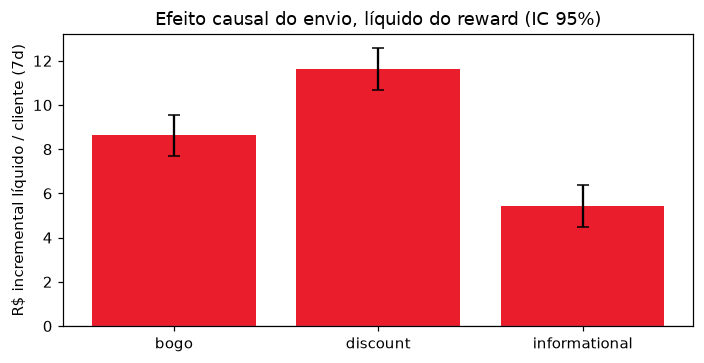

In [ ]:
# ATE agregado (pooled, ponderado por onda) e por tipo de oferta
pool_t = df[(df.W == 1) & (df.n_active_offers == 0)]
pool_c = df[df.control_clean == 1]
lo, hi = boot_ci(pool_t['y_net_h7'].values, pool_c['y_net_h7'].values)
ate_pool = pool_t['y_net_h7'].mean() - pool_c['y_net_h7'].mean()
print(f"ATE líquido 7d (tratado limpo vs controle limpo, pooled): "
      f"R$ {ate_pool:.2f} [{lo:.2f}, {hi:.2f}]  (n_t={len(pool_t):,}, n_c={len(pool_c):,})")

by_type = []
for t in ['bogo', 'discount', 'informational']:
    tt = pool_t[pool_t.offer_type == t]['y_net_h7'].values
    lo, hi = boot_ci(tt, pool_c['y_net_h7'].values, seed=1)
    by_type.append({'tipo': t, 'n': len(tt), 'ate_liq_7d': tt.mean() - pool_c['y_net_h7'].mean(),
                    'ic_lo': lo, 'ic_hi': hi})
by_type = pd.DataFrame(by_type)
print(by_type.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar(by_type.tipo, by_type.ate_liq_7d, color=IFOOD_RED,
       yerr=[by_type.ate_liq_7d - by_type.ic_lo, by_type.ic_hi - by_type.ate_liq_7d],
       capsize=4)
ax.axhline(0, color='grey', lw=.8)
ax.set_ylabel('R$ incremental líquido / cliente (7d)')
ax.set_title('Efeito causal do envio, líquido do reward (IC 95%)')
plt.tight_layout(); plt.savefig(f'{FIG}/05_ate.png', bbox_inches='tight'); plt.show()

**Leitura:** o envio gera incremento líquido positivo por cliente mesmo após
descontar o reward — e o efeito difere por tipo. Este é o *baseline* causal que a
política tenta melhorar via personalização (bloco D/E).

*Robustez:* ajuste por regressão (GBM com W + features pré-onda) abaixo — o efeito
ajustado deve ficar próximo da diferença de médias se o balance segurar.

In [ ]:
# ajuste por regressão: outcome ~ features, resíduo comparado entre W (pooled limpo)
adj = pd.concat([pool_t, pool_c])
m_adj = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.08,
                     subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
m_adj.fit(adj[X_CUST], adj['y_net_h7'])
resid = adj['y_net_h7'] - m_adj.predict(adj[X_CUST])
ate_adj = resid[adj.W == 1].mean() - resid[adj.W == 0].mean()
print(f"ATE ajustado por regressão: R$ {ate_adj:.2f} (dif. de médias: R$ {ate_pool:.2f})")

ATE ajustado por regressão: R$ 8.94 (dif. de médias: R$ 9.21)


### Robustez — bootstrap clusterizado por cliente
O mesmo cliente aparece em até 6 ondas (e pode estar tratado numa onda e controle
noutra); o bootstrap linha-a-linha assume independência que não existe. Aqui o
reamostramos **por cliente** (mantendo todas as suas linhas), que é o IC correto
sob correlação intra-cliente.

In [ ]:
def cluster_ci(t_df, c_df, n=2000, seed=0):
    pool = pd.concat([t_df.assign(_g=1), c_df.assign(_g=0)])
    agg = (pool.groupby(['account_id', '_g'])['y_net_h7'].agg(['sum', 'count'])
               .unstack('_g', fill_value=0))
    s0, n0 = agg[('sum', 0)].values, agg[('count', 0)].values
    s1, n1 = agg[('sum', 1)].values, agg[('count', 1)].values
    M = len(agg)
    r = np.random.RandomState(seed)
    diffs = np.empty(n)
    for i in range(n):
        idx = r.randint(0, M, M)
        diffs[i] = s1[idx].sum() / max(n1[idx].sum(), 1) - s0[idx].sum() / max(n0[idx].sum(), 1)
    return np.percentile(diffs, [2.5, 97.5])

lo_r, hi_r = boot_ci(pool_t['y_net_h7'].values, pool_c['y_net_h7'].values)
lo_cl, hi_cl = cluster_ci(pool_t, pool_c)
print(f"ATE pooled R$ {ate_pool:.2f} | IC linha-a-linha [{lo_r:.2f}, {hi_r:.2f}] "
      f"| IC clusterizado por cliente [{lo_cl:.2f}, {hi_cl:.2f}]")
for t in ['bogo', 'discount', 'informational']:
    lo_t, hi_t = cluster_ci(pool_t[pool_t.offer_type == t], pool_c, seed=1)
    print(f"  {t:13s}: IC clusterizado [{lo_t:.2f}, {hi_t:.2f}]")

ATE pooled R$ 9.21 | IC linha-a-linha [8.45, 9.90] | IC clusterizado por cliente [8.55, 9.93]


  bogo         : IC clusterizado [7.71, 9.59]


  discount     : IC clusterizado [10.70, 12.58]


  informational: IC clusterizado [4.49, 6.47]


## C · Modelo de resposta — `P(viu & usou | enviei, cliente, oferta)`
Treinado nos **tratados** das ondas 0–14; avaliado nas ondas 17–24 (fora do tempo).
XGBoost com features de cliente + atributos da oferta.

In [ ]:
tr_mask = (df.W == 1) & (df.split == 'train')
te_mask = (df.W == 1) & (df.split == 'test')
Xtr, ytr = df.loc[tr_mask, X_CUST + X_OFFER], df.loc[tr_mask, 'y_response']
Xte, yte = df.loc[te_mask, X_CUST + X_OFFER], df.loc[te_mask, 'y_response']

resp = XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8, eval_metric='logloss',
                     random_state=42, n_jobs=-1)
resp.fit(Xtr, ytr)
p_te = resp.predict_proba(Xte)[:, 1]
print(f"treino: {len(ytr):,} (resp {ytr.mean():.3f}) | teste: {len(yte):,} (resp {yte.mean():.3f})")
print(f"AUC teste temporal: {roc_auc_score(yte, p_te):.3f} | PR-AUC: {average_precision_score(yte, p_te):.3f}")

treino: 38,030 (resp 0.393) | teste: 38,247 (resp 0.384)
AUC teste temporal: 0.795 | PR-AUC: 0.676


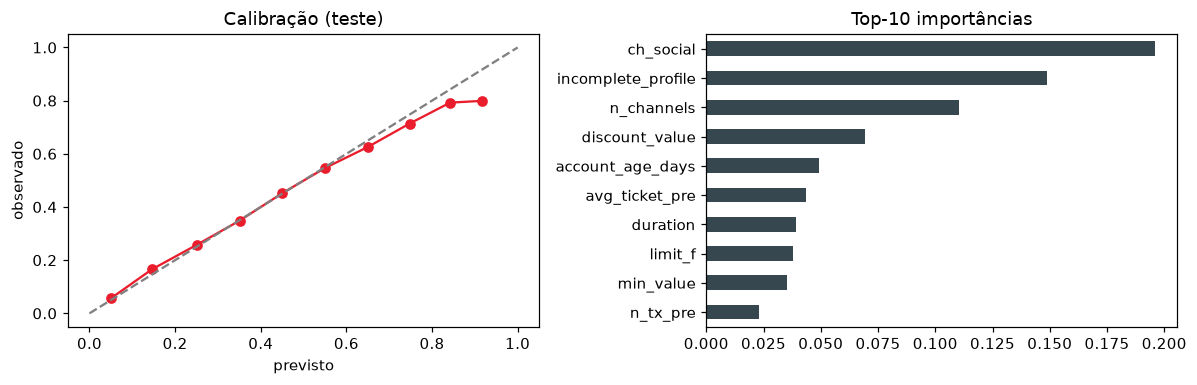

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
frac_pos, mean_pred = calibration_curve(yte, p_te, n_bins=10)
axes[0].plot(mean_pred, frac_pos, 'o-', color=IFOOD_RED)
axes[0].plot([0, 1], [0, 1], '--', color='grey')
axes[0].set_xlabel('previsto'); axes[0].set_ylabel('observado'); axes[0].set_title('Calibração (teste)')
imp = pd.Series(resp.feature_importances_, index=X_CUST + X_OFFER).nlargest(10)
imp.iloc[::-1].plot.barh(ax=axes[1], color='#37474F'); axes[1].set_title('Top-10 importâncias')
plt.tight_layout(); plt.savefig(f'{FIG}/06_response_model.png', bbox_inches='tight'); plt.show()

**Leitura:** o modelo de resposta ranqueia bem *quem usa* — mas isso, sozinho,
não decide o envio: quem responde muito pode ser exatamente quem já compraria
(custo de reward sem incremento). Por isso a política usa o **CATE líquido** (D).

## D · Efeito heterogêneo (CATE) — T-learner por tipo de oferta
- `m1_tipo(x, atributos_da_oferta)`: regressor do gasto líquido 7d nos **tratados do
  tipo** (ondas de treino);
- `m0(x)`: regressor do gasto 7d no **controle limpo** (ondas de treino);
- `CATE(x, oferta) = m1_tipo(x, oferta) − m0(x)`.

Atributos da oferta entram no braço → o CATE diferencia ofertas do mesmo tipo.

In [ ]:
def make_reg():
    return XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)

m0 = make_reg()
ctr_tr = df[(df.control_clean == 1) & (df.split == 'train')]
m0.fit(ctr_tr[X_CUST], ctr_tr['y_net_h7'])

m1 = {}
for t in ['bogo', 'discount', 'informational']:
    sub = df[(df.W == 1) & (df.offer_type == t) & (df.split == 'train')]
    m1[t] = make_reg()
    m1[t].fit(sub[X_CUST + X_OFFER], sub['y_net_h7'])
    print(f"braço {t:13s}: {len(sub):,} linhas de treino")
print(f"controle (m0): {len(ctr_tr):,}")

braço bogo         : 15,183 linhas de treino


braço discount     : 15,237 linhas de treino


braço informational: 7,610 linhas de treino
controle (m0): 11,650


### Validação do CATE — Qini nas ondas de teste (por tipo)
População: tratados do tipo + controle limpo (teste). Score = CATE previsto;
curva Qini no **gasto líquido incremental** acumulado (não AUC).

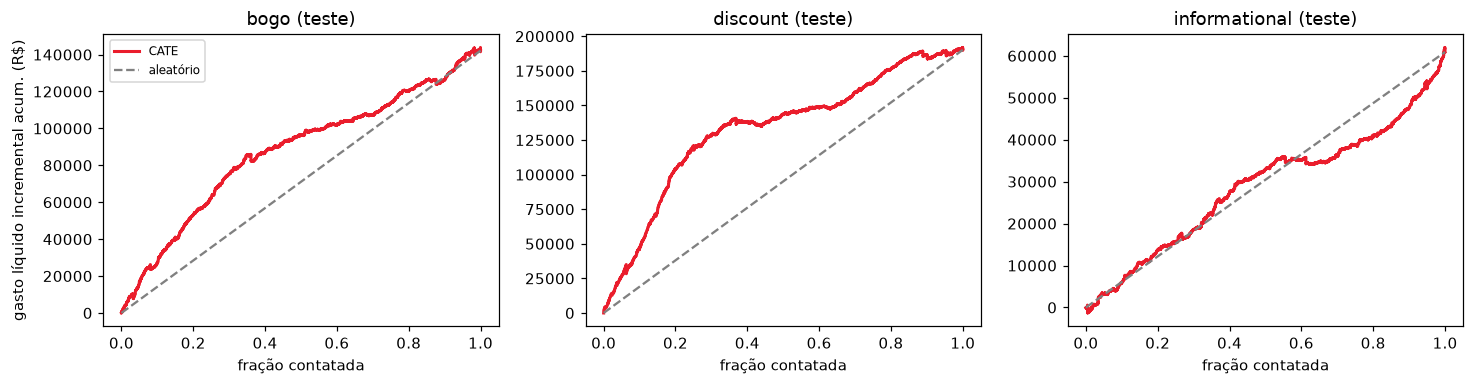

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6), sharey=False)
qini_res = {}
for ax, t in zip(axes, ['bogo', 'discount', 'informational']):
    tr_t = df[(df.W == 1) & (df.offer_type == t) & (df.split == 'test')].copy()
    ct_t = df[(df.control_clean == 1) & (df.split == 'test')].copy()
    # controle é pontuado com a oferta "média" do tipo (representante do braço)
    mean_attrs = offers[offers.offer_type == t][X_OFFER].mean()
    for col in X_OFFER:
        ct_t[col] = mean_attrs[col]
    both = pd.concat([tr_t, ct_t])
    score = m1[t].predict(both[X_CUST + X_OFFER]) - m0.predict(both[X_CUST])
    x, yq = qini_curve(both['y_net_h7'].values, both['W'].values, score)
    xr, yr = qini_curve(both['y_net_h7'].values, both['W'].values,
                        rng.rand(len(both)))
    ax.plot(x, yq, color=IFOOD_RED, lw=2, label='CATE')
    ax.plot([0, 1], [0, yq[-1]], '--', color='grey', label='aleatório')
    ax.set_title(f'{t} (teste)'); ax.set_xlabel('fração contatada')
    qini_res[t] = (yq, yr)
axes[0].set_ylabel('gasto líquido incremental acum. (R$)')
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.savefig(f'{FIG}/07_qini_test.png', bbox_inches='tight'); plt.show()

## E · Política de envio + impacto
Para cada cliente das ondas de teste: pontua as **10 ofertas candidatas** →
`argmax` do CATE líquido; **não envia** se o melhor CATE ≤ 0. Validação
*model-free*: uplift realizado (tratado × controle limpo) por faixa do score.

In [ ]:
test_cust = df[df.split == 'test'].drop_duplicates('account_id')[['account_id'] + X_CUST]
base0 = m0.predict(test_cust[X_CUST])

scores = {}
for _, o in offers.iterrows():
    G = test_cust.copy()
    for col in X_OFFER:
        G[col] = o[col]
    scores[o['offer_id']] = m1[o['offer_type']].predict(G[X_CUST + X_OFFER]) - base0
S = pd.DataFrame(scores, index=test_cust.account_id)
otype = offers.set_index('offer_id')['offer_type']

policy = pd.DataFrame({
    'best_offer': S.idxmax(axis=1),
    'best_cate': S.max(axis=1)})
policy['best_type'] = policy.best_offer.map(otype)
policy['send'] = policy.best_cate > 0
print(f"clientes (teste): {len(policy):,}")
print(f"não enviar (CATE ≤ 0): {(~policy.send).mean():.1%}")
print("\ntipo recomendado (entre envios):")
print(policy[policy.send].best_type.value_counts(normalize=True).round(3).to_string())
print("\noferta recomendada top-5:")
print(policy[policy.send].best_offer.map(
    offers.set_index('offer_id').apply(
        lambda r: f"{r.offer_type} min={r.min_value:.0f} desc={r.discount_value:.0f} dur={r.duration:.0f}", axis=1)
).value_counts().head().to_string())

clientes (teste): 17,000
não enviar (CATE ≤ 0): 5.1%

tipo recomendado (entre envios):
best_type
discount         0.642
informational    0.188
bogo             0.170

oferta recomendada top-5:
best_offer
discount min=10 desc=2 dur=10       9580
informational min=0 desc=0 dur=3    2525
bogo min=10 desc=10 dur=7           1465
bogo min=5 desc=5 dur=5              867
informational min=0 desc=0 dur=4     503


### Robustez — política sob restrição de diversidade
A política irrestrita concentra os envios em poucas ofertas. Riscos não modelados
(saturação, canibalização, portfólio) pedem diversificação — impomos um **teto de
participação por oferta** e realocamos (greedy: cada cliente recebe a melhor oferta
com capacidade disponível; nenhuma se CATE ≤ 0). Métrica: fração do valor
*model-based* da política irrestrita que sobrevive ao teto (comparação relativa —
não depende do nível absoluto do CATE).

In [ ]:
S_mat = S.values
order_cust = np.argsort(-S_mat.max(axis=1))

def greedy_policy(cap_share):
    cap = int(np.ceil(cap_share * len(S_mat)))
    used = np.zeros(S_mat.shape[1], dtype=int)
    total, sends = 0.0, 0
    for ci in order_cust:
        for oi in np.argsort(-S_mat[ci]):
            v = S_mat[ci, oi]
            if v <= 0:
                break
            if used[oi] < cap:
                used[oi] += 1; total += v; sends += 1
                break
    return total, sends, used

base_total, _, _ = greedy_policy(1.0)
rows = []
for cap in [1.0, 0.5, 0.4, 0.3, 0.2, 0.1]:
    tot, snd, used = greedy_policy(cap)
    rows.append({'teto_por_oferta': f'{cap:.0%}', 'envios': snd,
                 'valor_preservado': tot / base_total,
                 'share_maior_oferta': used.max() / max(snd, 1)})
divers = pd.DataFrame(rows)
print(divers.round(3).to_string(index=False))
v20 = divers.loc[divers.teto_por_oferta == '20%', 'valor_preservado'].iloc[0]
print(f"\n→ forçando nenhuma oferta a passar de 20% dos envios, "
      f"a política preserva {v20:.0%} do valor irrestrito")

teto_por_oferta  envios  valor_preservado  share_maior_oferta
           100%   16127             1.000               0.594
            50%   15922             0.997               0.534
            40%   15879             0.990               0.428
            30%   15864             0.977               0.321
            20%   15790             0.957               0.215
            10%   14354             0.887               0.118

→ forçando nenhuma oferta a passar de 20% dos envios, a política preserva 96% do valor irrestrito


### Validação model-free: uplift realizado por faixa do score da política

     faixa  n_t  n_c  uplift_liq_7d
   top 20% 7677  769          21.15
    20-40% 7623  822          16.22
    40-60% 7696  749          10.48
    60-80% 7620  825           2.82
bottom 20% 7631  815          -0.10


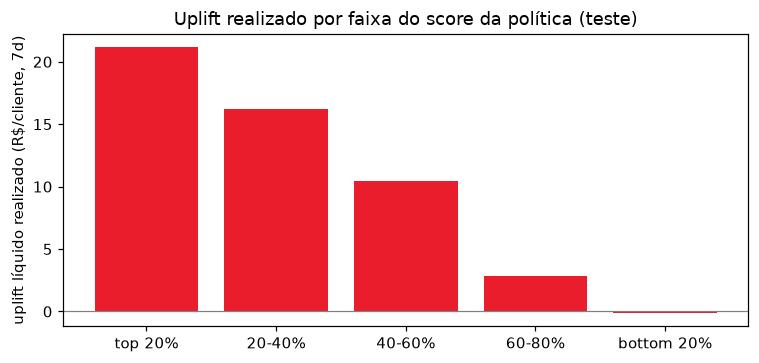

In [ ]:
# junta score da política às linhas de teste (tratados de qualquer tipo + controle limpo)
te = df[(df.split == 'test') & ((df.W == 1) | (df.control_clean == 1))].copy()
te = te.merge(policy[['best_cate']], left_on='account_id', right_index=True, how='inner')
te['faixa'] = pd.qcut(te.best_cate.rank(method='first', ascending=False), 5,
                      labels=['top 20%', '20-40%', '40-60%', '60-80%', 'bottom 20%'])
val = []
for f, g in te.groupby('faixa', observed=True):
    t, ctl = g[g.W == 1], g[g.W == 0]
    val.append({'faixa': f, 'n_t': len(t), 'n_c': len(ctl),
                'uplift_liq_7d': t.y_net_h7.mean() - ctl.y_net_h7.mean()})
val = pd.DataFrame(val)
print(val.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(val.faixa.astype(str), val.uplift_liq_7d, color=IFOOD_RED)
ax.axhline(0, color='grey', lw=.8)
ax.set_ylabel('uplift líquido realizado (R$/cliente, 7d)')
ax.set_title('Uplift realizado por faixa do score da política (teste)')
plt.tight_layout(); plt.savefig(f'{FIG}/08_policy_validation.png', bbox_inches='tight'); plt.show()

### Ganho de realocação de oferta (o coração do "qual oferta enviar")
A validação por faixas mostra que o score ranqueia bem **entre clientes**, mas não
mede o ganho de **trocar a oferta** de um mesmo cliente (só observamos a oferta
enviada). Estimamos a realocação de duas formas:
- **Piso (model-free):** realocar o mix para o tipo de maior ATE observado
  (discount) — usa só as diferenças de ATE do bloco B;
- **Teto (model-based):** CATE da melhor oferta vs CATE da oferta que foi de fato
  enviada — sujeito a **winner's curse** (argmax de predições ruidosas infla o
  máximo), por isso tratado como limite superior a validar em A/B.

In [ ]:
tt = df[(df.W == 1) & (df.split == 'test')].copy()
base_t = m0.predict(tt[X_CUST])
cate_sent = np.zeros(len(tt))
for t in ['bogo', 'discount', 'informational']:
    m = tt.offer_type.values == t
    cate_sent[m] = m1[t].predict(tt.loc[m, X_CUST + X_OFFER]) - base_t[m]
best_t = np.full(len(tt), -np.inf)
for _, o in offers.iterrows():
    G = tt[X_CUST].copy()
    for col in X_OFFER:
        G[col] = o[col]
    best_t = np.maximum(best_t, m1[o.offer_type].predict(G[X_CUST + X_OFFER]) - base_t)

print(f"CATE médio da oferta ENVIADA : R$ {cate_sent.mean():.2f}")
print(f"CATE médio da MELHOR oferta  : R$ {best_t.mean():.2f}")
print(f"já recebia a melhor oferta   : {np.isclose(best_t, cate_sent, atol=1e-6).mean():.1%}")
print(f"ganho de realocação (model-based, teto): R$ {(best_t - cate_sent).mean():.2f}/cliente")

ate_mix = pool_t['y_net_h7'].mean() - pool_c['y_net_h7'].mean()          # mix atual
ate_disc = by_type.loc[by_type.tipo == 'discount', 'ate_liq_7d'].iloc[0]  # melhor tipo
gain_floor = ate_disc / ate_mix - 1
print(f"ganho de realocação (model-free, piso — mix→discount): {gain_floor:+.1%}")

CATE médio da oferta ENVIADA : R$ 9.17
CATE médio da MELHOR oferta  : R$ 27.12
já recebia a melhor oferta   : 10.0%
ganho de realocação (model-based, teto): R$ 17.95/cliente
ganho de realocação (model-free, piso — mix→discount): +26.3%


### Robustez do piso — o ganho mix→discount vale em toda a base?
O piso compara ATEs médios; se a vantagem do discount vier só dos clientes de alto
gasto, realocar o mix não geraria o mesmo valor no restante da base. Recalculamos
**dentro de quintis de gasto pré-onda** (tratado limpo × controle limpo do mesmo
quintil). Reportamos a diferença em R$ (primária — a razão explode quando o ATE do
quintil é pequeno).

In [ ]:
pool_all = pd.concat([pool_t.assign(_g=1), pool_c.assign(_g=0)]).reset_index(drop=True)
# célula 0 = sem histórico de gasto (inclui onda 0); 1-4 = quartis do gasto positivo.
# (qcut por rank separaria os empates em 0 por ordem de concatenação — viés de célula)
pool_all['cell'] = 0
pos_m = pool_all.spend_pre > 0
pool_all.loc[pos_m, 'cell'] = pd.qcut(pool_all.loc[pos_m, 'spend_pre'], 4, labels=False) + 1
LBL = {0: 'sem histórico', 1: 'Q1 (baixo)', 2: 'Q2', 3: 'Q3', 4: 'Q4 (alto)'}
rows = []
for q, g in pool_all.groupby('cell'):
    ctl = g[g._g == 0]['y_net_h7']
    t_all = g[g._g == 1]['y_net_h7']
    t_disc = g[(g._g == 1) & (g.offer_type == 'discount')]['y_net_h7']
    a_mix = t_all.mean() - ctl.mean()
    a_disc = t_disc.mean() - ctl.mean()
    rows.append({'celula_gasto_pre': LBL[int(q)], 'n_t': len(t_all),
                 'n_t_disc': len(t_disc), 'n_c': len(ctl),
                 'ate_mix': a_mix, 'ate_discount': a_disc,
                 'ganho_R$': a_disc - a_mix})
sens = pd.DataFrame(rows)
print(sens.round(2).to_string(index=False))
ok = sens.dropna(subset=['ganho_R$'])
w_gain = np.average(ok['ganho_R$'], weights=ok['n_t'])
print(f"\n→ ganho positivo em {(ok['ganho_R$'] > 0).sum()}/{len(ok)} células | "
      f"média ponderada: R$ {w_gain:.2f}/cliente (pooled: R$ {ate_disc - ate_mix:.2f})")

celula_gasto_pre   n_t  n_t_disc  n_c  ate_mix  ate_discount  ganho_R$
   sem histórico 18581      7449 6348     8.39         11.07      2.68
      Q1 (baixo)  6888      2782 2361     2.44          2.96      0.52
              Q2  6933      2781 2308     6.33          7.39      1.06
              Q3  6924      2742 2318    10.88         13.88      3.00
       Q4 (alto)  6946      2732 2295    18.69         23.87      5.18

→ ganho positivo em 5/5 células | média ponderada: R$ 2.54/cliente (pooled: R$ 2.42)


### Simulação financeira (projeção por 1 milhão de envios)
Três cenários: **enviar a todos** (mix atual, realizado model-free nas ondas de
teste), **política conservadora** (piso: realoca o mix p/ o melhor tipo + corta
CATE ≤ 0) e **política personalizada** (teto model-based, a validar em A/B).

uplift líquido realizado (enviar a todos): R$ 10.28/cliente

projeção por 1,000,000 envios possíveis:
  enviar a todos (mix atual)      : R$ 10,281,074
  política — piso (model-free)    : R$ 12,321,055  (+20%, 95% dos envios)
  política — teto (model-based)   : R$ 29,417,061  (+186%) — validar em A/B


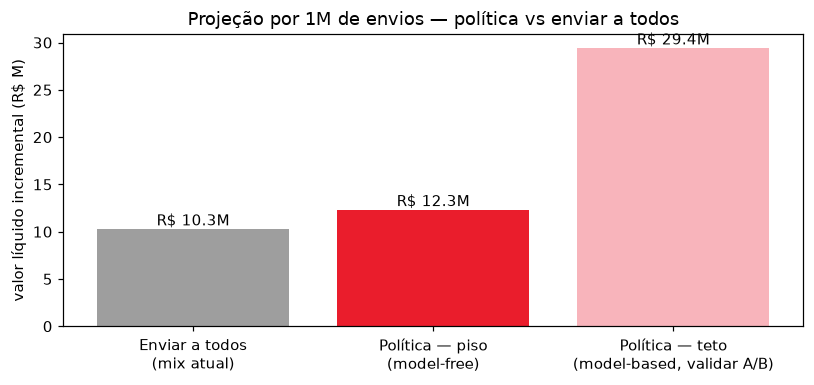

In [ ]:
POP = 1_000_000
frac_send = policy.send.mean()
overall_t = te[te.W == 1]; overall_c = te[te.W == 0]
up_all = overall_t.y_net_h7.mean() - overall_c.y_net_h7.mean()

val_all = POP * up_all
val_floor = POP * frac_send * up_all * (1 + gain_floor)
val_ceil = POP * frac_send * np.where(best_t > 0, best_t, 0).mean() / max(cate_sent.mean(), 1e-9) * up_all

print(f"uplift líquido realizado (enviar a todos): R$ {up_all:.2f}/cliente")
print(f"\nprojeção por {POP:,} envios possíveis:")
print(f"  enviar a todos (mix atual)      : R$ {val_all:,.0f}")
print(f"  política — piso (model-free)    : R$ {val_floor:,.0f}  ({val_floor/val_all-1:+.0%}, {frac_send:.0%} dos envios)")
print(f"  política — teto (model-based)   : R$ {val_ceil:,.0f}  ({val_ceil/val_all-1:+.0%}) — validar em A/B")

fig, ax = plt.subplots(figsize=(7.5, 3.6))
vals = [val_all/1e6, val_floor/1e6, val_ceil/1e6]
ax.bar(['Enviar a todos\n(mix atual)', 'Política — piso\n(model-free)',
        'Política — teto\n(model-based, validar A/B)'],
       vals, color=['#9E9E9E', IFOOD_RED, '#F8B4BB'])
for i, v in enumerate(vals):
    ax.text(i, v, f'R$ {v:.1f}M', ha='center', va='bottom')
ax.set_ylabel('valor líquido incremental (R$ M)')
ax.set_title('Projeção por 1M de envios — política vs enviar a todos')
plt.tight_layout(); plt.savefig(f'{FIG}/09_business_impact.png', bbox_inches='tight'); plt.show()

## Conclusões
1. **O envio causa incremento líquido** (ATE > 0 mesmo descontando reward), com
   heterogeneidade relevante por tipo (discount > bogo > informational) e por cliente.
2. O **modelo de resposta** (viu & usou) ranqueia bem fora do tempo, mas a decisão
   de envio é guiada pelo **CATE líquido** — evita pagar reward a quem compraria de
   qualquer forma.
3. A **política** (melhor oferta por cliente; "nenhuma" quando CATE ≤ 0) tem ganho
   apresentado como **range**: piso model-free (realocação de mix por tipo) e teto
   model-based (personalização total, sujeito a winner's curse) — com o ranking
   validado *model-free* por faixas de score nas ondas de teste (uplift realizado
   monotônico do topo à base).

### Limitações e próximos passos
- Envio ~aleatorizado é premissa (balance check favorável); validação definitiva =
  **A/B test** com holdout.
- `reward_paid` da janela da oferta vs horizonte 7d: aproximação conservadora.
- Ondas de teste têm controle limpo menor (1,2–1,4k/onda) → ICs largos por faixa.
- Produção: re-treino por onda, monitoramento de calibração/drift, restrição de
  orçamento (knapsack uplift/custo), otimização de timing e canal.
